## **Modeling & Evaluation (KNN) Suara Buka Tutup**

### ***1. Import & Load Data Fitur***

In [9]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

# Load dataset dengan fitur terpilih
train_df = pd.read_csv("train_features_selected.csv")
val_df   = pd.read_csv("val_features_selected.csv")

print(f"Data Train: {train_df.shape}, Data Val: {val_df.shape}")
print(f"Menggunakan {train_df.shape[1] - 1} fitur terpilih")
train_df.head()

Data Train: (160, 6), Data Val: (40, 6)
Menggunakan 5 fitur terpilih


,mel_7_std,chroma_0_mean,mel_6_std,stat_skew,mel_7_mean,label
0,0.003948,0.466429,0.008969,0.831375,0.002202,buka
1,0.084030,0.416597,0.060875,2.285544,0.028887,tutup
2,0.001691,0.376447,0.006055,1.768264,0.001273,buka
3,0.013888,0.387179,0.004689,-0.550398,0.005761,tutup
4,0.030463,0.424229,0.046075,2.255194,0.008507,tutup


### ***2. Pisahkan Fitur dan Label***

In [10]:
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']

X_val = val_df.drop(columns=['label'])
y_val = val_df['label']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Data telah dinormalisasi untuk KNN")
print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_val shape: {X_val_scaled.shape}")

Data telah dinormalisasi untuk KNN
X_train shape: (160, 5)
X_val shape: (40, 5)


### ***3. Membuat dan Latih Model KNN***

In [11]:
k_values = [3, 5, 8, 9, 11, 15]
best_k = 3
best_acc = 0

print("Testing different K values:")
for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_temp.fit(X_train_scaled, y_train)
    temp_pred = knn_temp.predict(X_val_scaled)
    temp_acc = accuracy_score(y_val, temp_pred)
    print(f"K={k}: Accuracy = {temp_acc*100:.2f}%")
    
    if temp_acc > best_acc:
        best_acc = temp_acc
        best_k = k

print(f"\nBest K value: {best_k} with accuracy: {best_acc*100:.2f}%")

# Train final model dengan best K
knn_model = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean',
    weights='uniform'
)

knn_model.fit(X_train_scaled, y_train)

Testing different K values:
K=3: Accuracy = 87.50%
K=5: Accuracy = 87.50%
K=8: Accuracy = 90.00%
K=9: Accuracy = 85.00%
K=11: Accuracy = 82.50%
K=15: Accuracy = 82.50%

Best K value: 8 with accuracy: 90.00%


,n_neighbors,8
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


### ***4. Evaluasi Model di Data Validation***

In [12]:
y_pred = knn_model.predict(X_val_scaled)

acc = accuracy_score(y_val, y_pred)
print(f"Akurasi Model KNN (K={best_k}): {acc*100:.2f}%\n")

print("=== Classification Report ===")
print(classification_report(y_val, y_pred))

# Save model dan scaler
joblib.dump(knn_model, 'model_results/knn_model_buka_tutup.pkl')
joblib.dump(scaler, 'model_results/scaler_buka_tutup.pkl')
print("\nModel dan scaler telah disimpan!")

Akurasi Model KNN (K=8): 90.00%

=== Classification Report ===
              precision    recall  f1-score   support

        buka       0.90      0.90      0.90        20
       tutup       0.90      0.90      0.90        20

    accuracy                           0.90        40
   macro avg       0.90      0.90      0.90        40
weighted avg       0.90      0.90      0.90        40


Model dan scaler telah disimpan!


### ***5. Confusion Matrix Visualization***

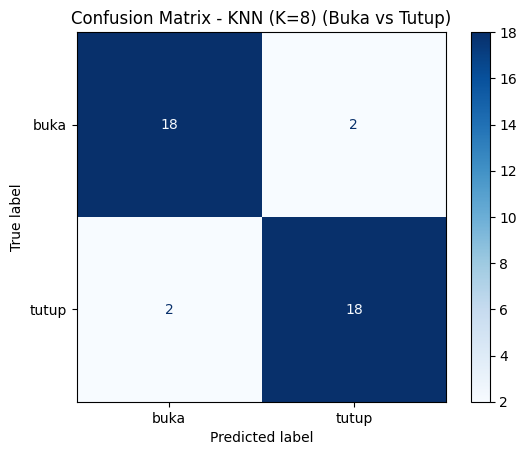

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_pred, labels=knn_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_model.classes_)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix - KNN (K={best_k}) (Buka vs Tutup)")
plt.show()


### ***6. Visualisasi Performa K-Values***

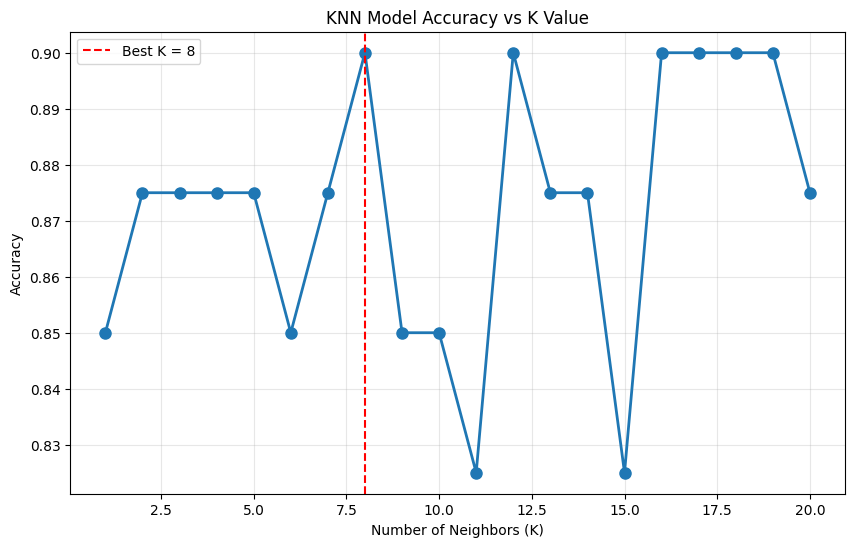

Optimal K value: 8
Maximum accuracy: 90.00%


In [14]:
k_range = range(1, 21)
accuracies = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    temp_pred = knn_temp.predict(X_val_scaled)
    accuracies.append(accuracy_score(y_val, temp_pred))

plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linewidth=2, markersize=8)
plt.title('KNN Model Accuracy vs K Value')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.legend()
plt.show()

print(f"Optimal K value: {best_k}")
print(f"Maximum accuracy: {max(accuracies)*100:.2f}%")

### ***7. Prediksi Suara Buka Tutup***

In [15]:
import os
import librosa
import numpy as np
import pandas as pd
from scipy import stats
import IPython.display as ipd

In [17]:
import os
import librosa
import numpy as np
import pandas as pd
from scipy import stats
import IPython.display as ipd

def extract_only_selected_features(y, sr=22050):
    feats = {}
    
    feats['stat_skew'] = stats.skew(y)
    
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    feats['chroma_0_mean'] = np.mean(chroma[0])
    
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=10)
    feats['mel_6_std'] = np.std(mel_spec[6])
    feats['mel_7_mean'] = np.mean(mel_spec[7])
    feats['mel_7_std'] = np.std(mel_spec[7])
    
    return feats

def find_audio_file():
    buka_folder = "dataset48k/train/buka/"
    if os.path.exists(buka_folder):
        audio_files = [f for f in os.listdir(buka_folder) if f.endswith('.wav')]
        if audio_files:
            return os.path.join(buka_folder, audio_files[90])
    return None

# Main prediction
test_file = find_audio_file()
knn_model = joblib.load('model_results/knn_model_buka_tutup.pkl')
scaler = joblib.load('model_results/scaler_buka_tutup.pkl')

if test_file is None:
    print("Tidak ada file audio yang ditemukan!")
else:
    print(f"Menggunakan file: {test_file}")
    
    # Tampilkan audio
    ipd.display(ipd.Audio(test_file))
    
    # Preprocess (sama seperti saat training)
    y, sr = librosa.load(test_file, sr=22050)
    
    # Durasi 1 detik
    max_len = int(sr * 1.0)
    if len(y) < max_len:
        y = np.pad(y, (0, max_len - len(y)), mode='constant')
    else:
        y = y[:max_len]
    
    # Normalisasi
    y = y / np.max(np.abs(y) + 1e-6)
    
    # Noise reduction
    y[np.abs(y) < 0.005] = 0.0
    
    selected_features = extract_only_selected_features(y, sr)
    
    print(f"\n🔍 FITUR YANG DIEKSTRAKSI:")
    print(f"{'='*40}")
    for feat_name, feat_value in selected_features.items():
        print(f"{feat_name:<15}: {feat_value:.6f}")
    
    feature_order = ['mel_7_std', 'chroma_0_mean', 'mel_6_std', 'stat_skew', 'mel_7_mean']
    X_new = pd.DataFrame([selected_features])[feature_order]
    
    # PENTING: Scale data baru dengan scaler yang sama
    X_new_scaled = scaler.transform(X_new)
    
    print(f"\nINPUT SHAPE: {X_new.shape}")
    print(f"FEATURE ORDER: {list(X_new.columns)}")
    print(f"Data telah di-scale untuk KNN")
    
    # Prediksi dengan KNN
    pred_label = knn_model.predict(X_new_scaled)[0]
    pred_proba = knn_model.predict_proba(X_new_scaled)[0]
    
    # Get nearest neighbors for explanation
    distances, indices = knn_model.kneighbors(X_new_scaled)
    
    print(f"\nHASIL PREDIKSI KNN (K={knn_model.n_neighbors})")
    print(f"{'='*40}")
    print(f"Prediksi: **{pred_label.upper()}**")
    print(f"Confidence: {max(pred_proba)*100:.1f}%")
    
    classes = knn_model.classes_
    for i, cls in enumerate(classes):
        print(f"P({cls}): {pred_proba[i]*100:.1f}%")
    
    print(f"\nNearest Neighbors Info:")
    print(f"Distances to {knn_model.n_neighbors} nearest neighbors: {distances[0]}")
    print(f"Training samples indices: {indices[0]}")

Menggunakan file: dataset48k/train/buka/Buka46.wav



🔍 FITUR YANG DIEKSTRAKSI:
stat_skew      : 0.370864
chroma_0_mean  : 0.601588
mel_6_std      : 0.002175
mel_7_mean     : 0.000546
mel_7_std      : 0.001194

INPUT SHAPE: (1, 5)
FEATURE ORDER: ['mel_7_std', 'chroma_0_mean', 'mel_6_std', 'stat_skew', 'mel_7_mean']
Data telah di-scale untuk KNN

HASIL PREDIKSI KNN (K=8)
Prediksi: **BUKA**
Confidence: 100.0%
P(buka): 100.0%
P(tutup): 0.0%

Nearest Neighbors Info:
Distances to 8 nearest neighbors: [2.95522316e-08 1.46439356e-01 1.60411627e-01 1.81995526e-01
 1.82855523e-01 1.99407426e-01 2.32403080e-01 2.38810776e-01]
Training samples indices: [ 20  85   6 137  81  98 105  15]
